# Reconnaissance de sort (magique)
## 1. Explication du projet
Nous allons créer un projet machine learning pour reconnaître différents sorts et passer par toute la chaîne d'apprentissage: de l'acquisition des données brutes, leur split et leur pré-traitement, l'entraînement du modèle avec les données d'entraînement, et le test du modèle obtenu. L'analyse des métriques sera également étudié. 

## 2. Upload d'un dataset


In [1]:
!pip install cbor2

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#Upload du fichier zip contenant les données brutes
import zipfile
import os

zip_path = "reconnaissance-de-sort-export.zip" #Création d'une variable contenant le nom du fichier zip à ouvrir
data_sort = "edge_impulse_data" #Création d'une variable contenant le nom du fichier où on veut extraire le fichier zip

#Décompression du fichier zip vers la variable sort
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(data_sort)

#Que contient le fichier zip extrait
os.listdir(data_sort)

['info.labels', 'README.txt', 'testing', 'training']

In [3]:
#Création d'un tableau panda qui contient toutes les données (train et test)

import glob
import cbor2
import pandas as pd
import os

#Récuperation de tous les fichiers CBOR
files = glob.glob("edge_impulse_data/**/*.cbor", recursive=True)

#Structure des fichiers CBOR: protected, signature, payload
#Payload contient les données du capteur 

dfs = []

for file in files:
    with open(file, "rb") as f:
        d = cbor2.load(f)

    payload = d["payload"] #On isole la partie contenant les données du capteur

    colonnes = [sensor["name"] for sensor in payload["sensors"]] #Récupération du nom des capteurs

    df = pd.DataFrame(payload["values"], columns=colonnes) #Transformation des mesures en tableau

    df["source_file"] = file #Chemin de la donnée
    df["dataset"] = "training" if "training" in file else "testing" #Rajout d'une colonne pour différencier les données de training et de test
    df["label"] = os.path.basename(file).split(".")[0] #Rajout d'une colonne pour le label

    dfs.append(df) # dfs contient un tableau pour chaque fichier cbor

data = pd.concat(dfs, ignore_index=True) #on fusionne tous les tableau

data.head() #affiche les 5 premières lignes du tableau final


,accX,accY,accZ,gyrX,gyrY,gyrZ,source_file,dataset,label
0,9.534309,-1.403002,2.011728,-2.159119,-0.549316,-1.220703,edge_impulse_data\testing\Expelliarmus.6r4pg4t...,testing,Expelliarmus
1,9.517550,-1.230620,1.781885,-2.746582,-2.304077,1.037598,edge_impulse_data\testing\Expelliarmus.6r4pg4t...,testing,Expelliarmus
2,9.494206,-1.290475,1.913566,-6.858826,-4.867554,2.189636,edge_impulse_data\testing\Expelliarmus.6r4pg4t...,testing,Expelliarmus
3,9.528324,-1.015141,2.046444,-8.300781,-5.554199,3.440857,edge_impulse_data\testing\Expelliarmus.6r4pg4t...,testing,Expelliarmus
4,9.487623,-0.735020,2.338537,-6.721497,-3.730774,0.755310,edge_impulse_data\testing\Expelliarmus.6r4pg4t...,testing,Expelliarmus


# 3. Répartition des données en training/test

In [72]:
import matplotlib.pyplot as plt

# Séparer les données selon la colonne "dataset"
train_data = data[data["dataset"] == "training"]
test_data = data[data["dataset"] == "testing"]

# Afficher les dimensions
print("Nombre de lignes training :", len(train_data))
print("Nombre de lignes testing :", len(test_data))

print("Shape training :", train_data.shape)
print("Shape testing :", test_data.shape)

Nombre de lignes training : 70425
Nombre de lignes testing : 23475
Shape training : (70425, 9)
Shape testing : (23475, 9)


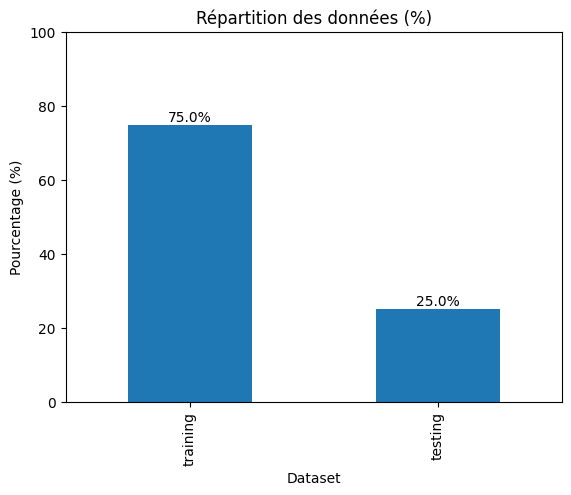

In [73]:
split_percent = (
    data["dataset"]
    .value_counts(normalize=True)
    .mul(100)
)

ax = split_percent.plot(kind="bar")

plt.title("Répartition des données (%)")
plt.xlabel("Dataset")
plt.ylabel("Pourcentage (%)")
plt.ylim(0, 100)

for i, v in enumerate(split_percent):
    ax.text(i, v + 1, f"{v}%", ha="center")

plt.show()

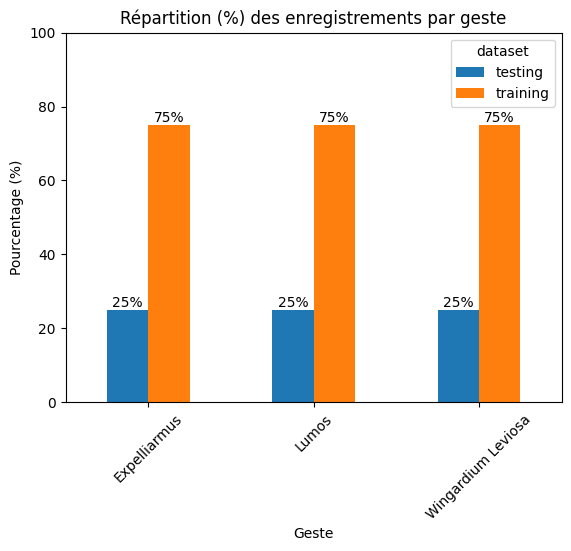

In [74]:
label_split = (
    data.groupby(["label", "dataset"])["source_file"]
        .nunique()
        .unstack(fill_value=0)
)

# Conversion en pourcentage par geste
label_split_percent = (
    label_split.div(label_split.sum(axis=1), axis=0) * 100
)

ax = label_split_percent.plot(kind="bar")

plt.title("Répartition (%) des enregistrements par geste")
plt.xlabel("Geste")
plt.ylabel("Pourcentage (%)")
plt.xticks(rotation=45)
plt.ylim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt="%.f%%")

plt.show()

# 4. Analyse spectrale


In [75]:
#Choix d'une donnée à analyser
import matplotlib.pyplot as plt
import numpy as np

# Choisir un fichier/enregistrement
sample_file = (
    data[
        (data["dataset"] == "training") &
        (data["label"] == "Expelliarmus")
    ]["source_file"]
    .iloc[0]
)

sample = data[data["source_file"] == sample_file]


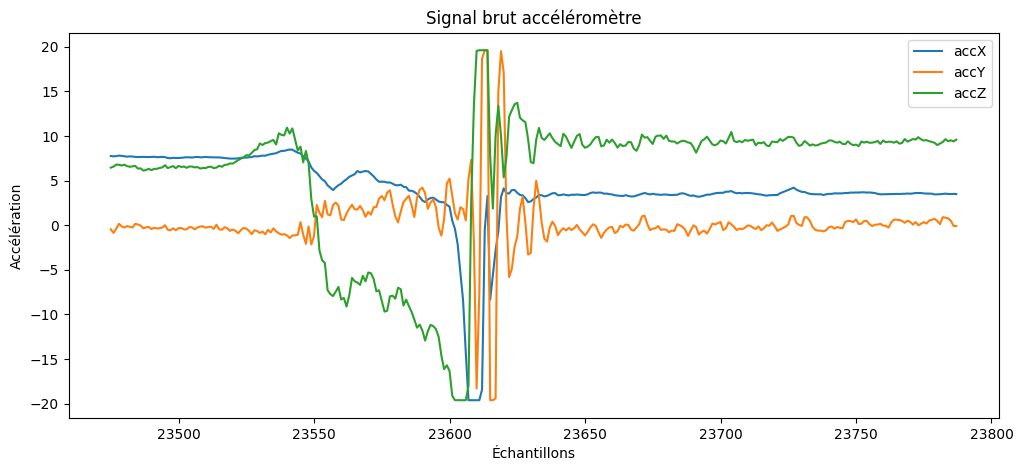

In [76]:
#Image en temporel de la donnée brute
plt.figure(figsize=(12, 5))

plt.plot(sample["accX"], label="accX")
plt.plot(sample["accY"], label="accY")
plt.plot(sample["accZ"], label="accZ")

plt.title("Signal brut accéléromètre")
plt.xlabel("Échantillons")
plt.ylabel("Accélération")
plt.legend()
plt.show()

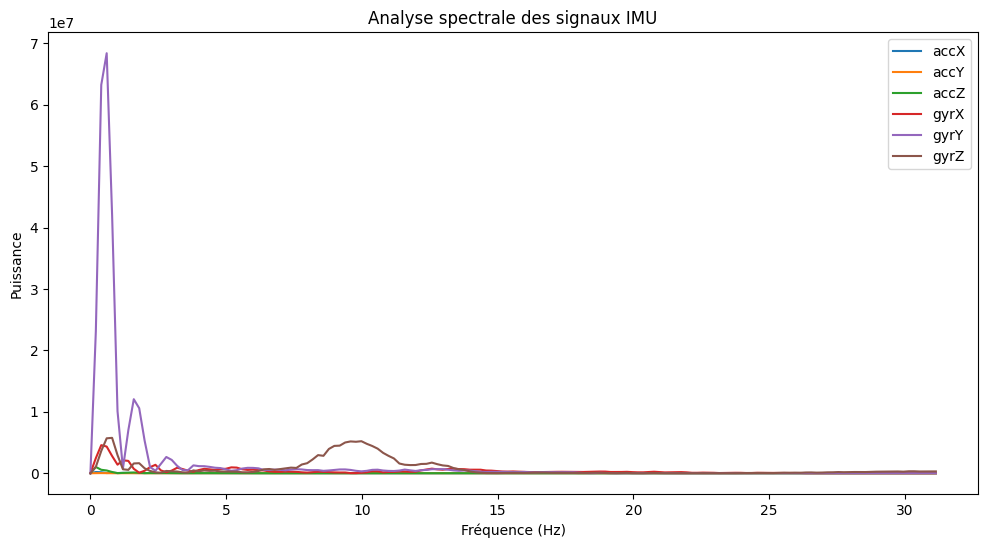

In [77]:
#Analyse spectrale 

# Fréquence d'échantillonnage
interval_ms = 16  # à adapter si ton Edge Impulse utilise une autre valeur
fs = 1000 / interval_ms

axes = ["accX", "accY", "accZ", "gyrX", "gyrY", "gyrZ"]

plt.figure(figsize=(12, 6))

#Application d'une analyse FFT

for axis in axes:
    signal = sample[axis].values
    signal = signal - np.mean(signal) #On enlève la composante continue

    fft_values = np.fft.rfft(signal)
    power = np.abs(fft_values) ** 2
    fft_freqs = np.fft.rfftfreq(len(signal), d=1/fs)

    plt.plot(fft_freqs, power, label=axis)

plt.title("Analyse spectrale des signaux IMU")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Puissance")
plt.legend()
plt.show()

# 5. Génération de features

In [78]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

axes = ["accX", "accY", "accZ", "gyrX", "gyrY", "gyrZ"]

def generate_spectral_features(sample, axes, n_fft=20):
    features = {}

    for axis in axes:
        signal = sample[axis].values

        # Enlever la moyenne
        signal = signal - np.mean(signal)

        # Features statistiques
        features[f"{axis}_rms"] = np.sqrt(np.mean(signal ** 2))
        features[f"{axis}_skewness"] = skew(signal)
        features[f"{axis}_kurtosis"] = kurtosis(signal)

        # FFT
        fft_values = np.fft.rfft(signal)
        power = np.abs(fft_values) ** 2

        # Filtrage des fréquences hautes (passe-bas)
        power = power[:n_fft]

        for i, value in enumerate(power):
            features[f"{axis}_fft_{i}"] = value

    return features

In [79]:
feature_rows = []

for source_file, sample in data.groupby("source_file"):
    features = generate_spectral_features(sample, axes, n_fft=20)

    features["source_file"] = source_file
    features["dataset"] = sample["dataset"].iloc[0]
    features["label"] = sample["label"].iloc[0]

    feature_rows.append(features)

features_df = pd.DataFrame(feature_rows)

features_df.head()

,accX_rms,accX_skewness,accX_kurtosis,accX_fft_0,accX_fft_1,accX_fft_2,accX_fft_3,accX_fft_4,accX_fft_5,accX_fft_6,...,gyrZ_fft_13,gyrZ_fft_14,gyrZ_fft_15,gyrZ_fft_16,gyrZ_fft_17,gyrZ_fft_18,gyrZ_fft_19,source_file,dataset,label
0,4.523338,-3.195857,14.298435,5.566203e-27,349198.794990,87589.811780,83305.544229,58768.932915,79165.850190,26247.345120,...,382175.775804,7.866990e+05,1.386719e+06,1.049963e+06,8.151981e+05,810711.875452,954096.307207,edge_impulse_data\testing\Expelliarmus.6r4pg4t...,testing,Expelliarmus
1,3.412110,-0.523391,0.523382,1.267349e-26,372095.455390,28618.784983,19847.559943,15232.536574,31146.539811,19088.110837,...,634983.459366,7.345382e+05,9.670989e+05,6.095368e+05,1.059283e+06,836384.406243,264728.563237,edge_impulse_data\testing\Expelliarmus.6r4pgjk...,testing,Expelliarmus
2,4.144179,-3.419116,17.596686,1.145446e-26,290084.307365,39941.965739,63322.061462,17165.045366,42231.732473,28548.103948,...,559510.568749,1.274347e+06,6.232132e+05,4.942691e+05,5.773413e+04,67901.260415,52221.024472,edge_impulse_data\testing\Expelliarmus.6r4pgvo...,testing,Expelliarmus
3,4.775494,-3.249951,13.335801,1.669230e-27,440188.065450,35556.263760,79378.834642,98854.117035,37656.862530,50271.553310,...,337548.440058,1.813768e+05,3.397223e+03,1.821875e+05,1.004094e+05,65245.048269,163450.604271,edge_impulse_data\testing\Expelliarmus.6r4phcm...,testing,Expelliarmus
4,4.314605,-3.700677,18.318590,4.319802e-27,339696.047134,50192.203004,23783.416377,63674.743137,41391.709276,25574.732354,...,32453.705671,6.007375e+04,1.283318e+04,9.997685e+04,1.001508e+05,22512.885553,46767.682346,edge_impulse_data\testing\Expelliarmus.6r4phpj...,testing,Expelliarmus


In [80]:
features_df.shape

(300, 141)

In [81]:
features_df.groupby("dataset").size()

dataset
testing      75
training    225
dtype: int64

In [82]:
train_features = features_df[features_df["dataset"] == "training"]
test_features = features_df[features_df["dataset"] == "testing"]

X_train = train_features.drop(columns=["source_file", "dataset", "label"])
y_train = train_features["label"]

X_test = test_features.drop(columns=["source_file", "dataset", "label"])
y_test = test_features["label"]

# 6. Classification sur données d'entraînement

In [83]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt

In [84]:
train_features = features_df[features_df["dataset"] == "training"]

X = train_features.drop(columns=["source_file", "dataset", "label"])
y = train_features["label"]

In [85]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['Expelliarmus' 'Lumos' 'Wingardium Leviosa']


In [86]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

In [87]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [88]:
num_features = X_train_scaled.shape[1]
num_classes = len(label_encoder.classes_)

model = Sequential([
    Dense(64, activation="relu", input_shape=(num_features,)),
    Dropout(0.3),

    Dense(32, activation="relu"),
    Dropout(0.3),

    Dense(num_classes, activation="softmax")
])

C:\Program Files\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [89]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [90]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=200,
    batch_size=16,
    callbacks=[early_stop]
)

Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.5444 - loss: 1.0438 - val_accuracy: 0.9333 - val_loss: 0.3706
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8056 - loss: 0.4659 - val_accuracy: 0.9778 - val_loss: 0.1634
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9056 - loss: 0.2729 - val_accuracy: 0.9778 - val_loss: 0.0835
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9444 - loss: 0.1748 - val_accuracy: 0.9778 - val_loss: 0.0474
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9722 - loss: 0.1145 - val_accuracy: 1.0000 - val_loss: 0.0279
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9611 - loss: 0.1058 - val_accuracy: 1.0000 - val_loss: 0.0180
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9833 - loss: 0.0495 - val_accuracy: 1.0000 - val_loss: 0.0123
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9833 - loss: 0.0769 - val_accuracy: 1.0000 - 

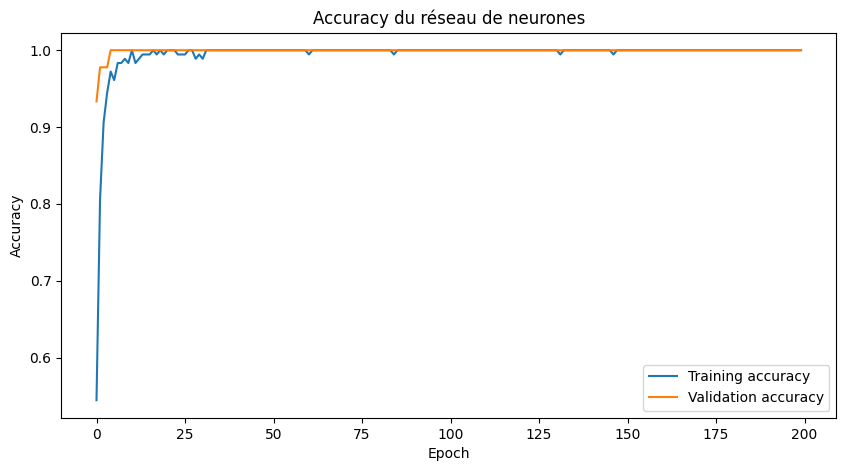

In [91]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")

plt.title("Accuracy du réseau de neurones")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

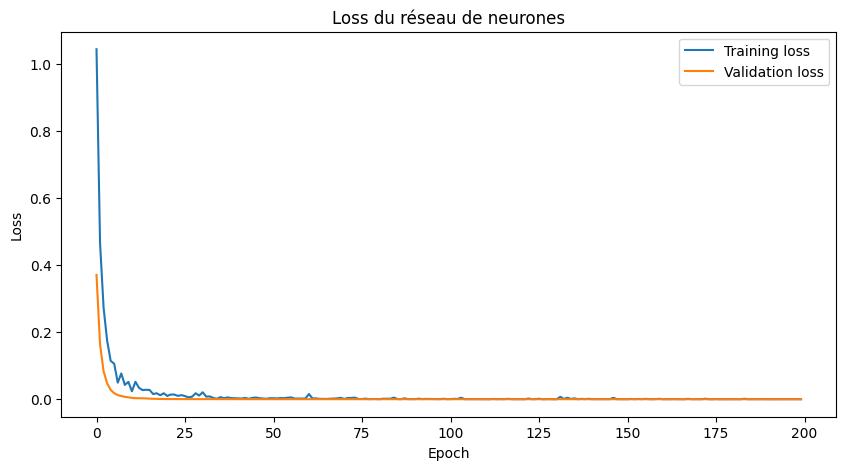

In [92]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")

plt.title("Loss du réseau de neurones")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [93]:
y_val_proba = model.predict(X_val_scaled)
y_val_pred = np.argmax(y_val_proba, axis=1)

print(classification_report(
    y_val,
    y_val_pred,
    target_names=label_encoder.classes_
))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
                    precision    recall  f1-score   support

      Expelliarmus       1.00      1.00      1.00        15
             Lumos       1.00      1.00      1.00        15
Wingardium Leviosa       1.00      1.00      1.00        15

          accuracy                           1.00        45
         macro avg       1.00      1.00      1.00        45
      weighted avg       1.00      1.00      1.00        45



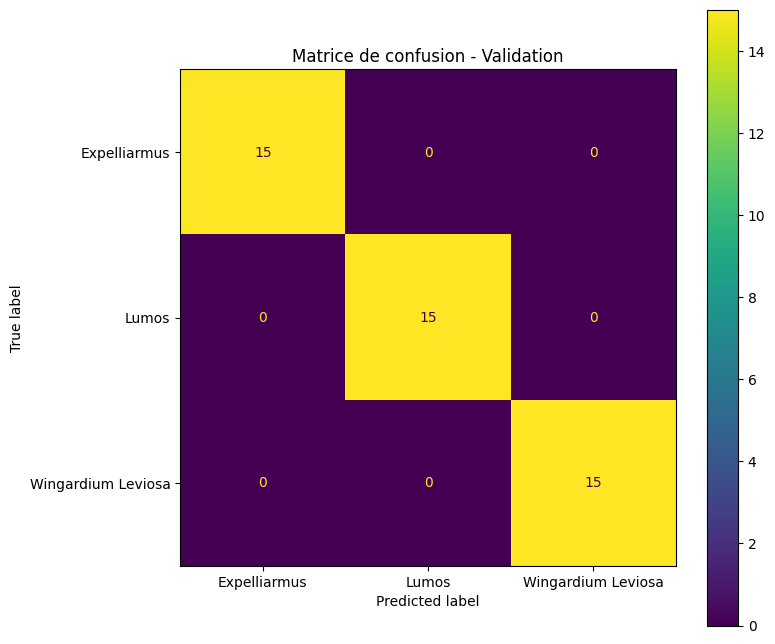

In [94]:
cm = confusion_matrix(y_val, y_val_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax)

plt.title("Matrice de confusion - Validation")
plt.show()

In [95]:
gap = (
    history.history["accuracy"][-1]
    - history.history["val_accuracy"][-1]
)

print("Écart :", gap)

Écart : 0.0


# 7. Test du modèle sur les données de test

In [96]:
test_features = features_df[
    features_df["dataset"] == "testing"
]

X_test = test_features.drop(
    columns=["source_file", "dataset", "label"]
)

y_test = test_features["label"]

In [97]:
y_test_encoded = label_encoder.transform(y_test)

In [98]:
X_test_scaled = scaler.transform(X_test)

In [99]:
y_test_proba = model.predict(X_test_scaled)

y_test_pred = np.argmax(
    y_test_proba,
    axis=1
)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [100]:
from sklearn.metrics import accuracy_score

test_accuracy = accuracy_score(
    y_test_encoded,
    y_test_pred
)

print(
    f"Accuracy sur le jeu de test : {test_accuracy:.4f}"
)

Accuracy sur le jeu de test : 1.0000


In [101]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_encoded,
        y_test_pred,
        target_names=label_encoder.classes_
    )
)

                    precision    recall  f1-score   support

      Expelliarmus       1.00      1.00      1.00        25
             Lumos       1.00      1.00      1.00        25
Wingardium Leviosa       1.00      1.00      1.00        25

          accuracy                           1.00        75
         macro avg       1.00      1.00      1.00        75
      weighted avg       1.00      1.00      1.00        75



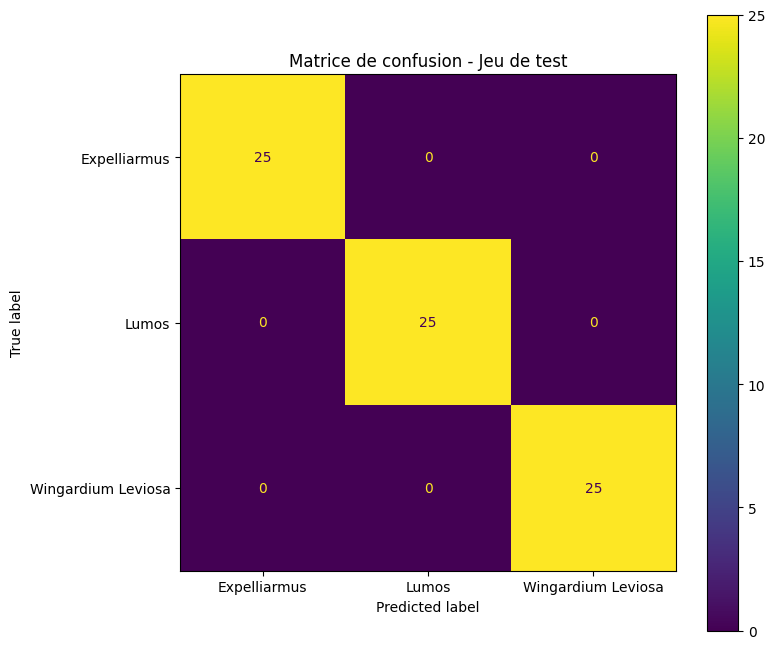

In [102]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test_encoded,
    y_test_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax)

plt.title("Matrice de confusion - Jeu de test")
plt.show()

In [103]:
print(
    "Accuracy validation :",
    max(history.history["val_accuracy"])
)

print(
    "Accuracy test :",
    test_accuracy
)

Accuracy validation : 1.0
Accuracy test : 1.0
